In [6]:
import pandas as pd
df=pd.read_csv("decisiontree.csv")
print(df.head())
print(df["target"].value_counts())

   age  gender  cp  trestbps  chol  fbs  thalach  exang  oldpeak  ca  target
0   49       0   3       177   150    0       95      0      2.3   0       0
1   56       1   0       124   172    1       85      1      0.5   0       1
2   66       0   3       100   239    0      105      0      1.7   0       0
3   64       0   0       168   222    0       95      1      2.8   0       1
4   60       1   3       153   358    0      147      0      3.2   0       0
0    8
1    7
Name: target, dtype: int64


In [7]:
X=df.drop("target", axis=1)
y=df["target"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(
X,y, test_size=0.2, random_state=42
) 

In [8]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred=dt.predict(X_test)
print(pred[:10])

[0 1 0]


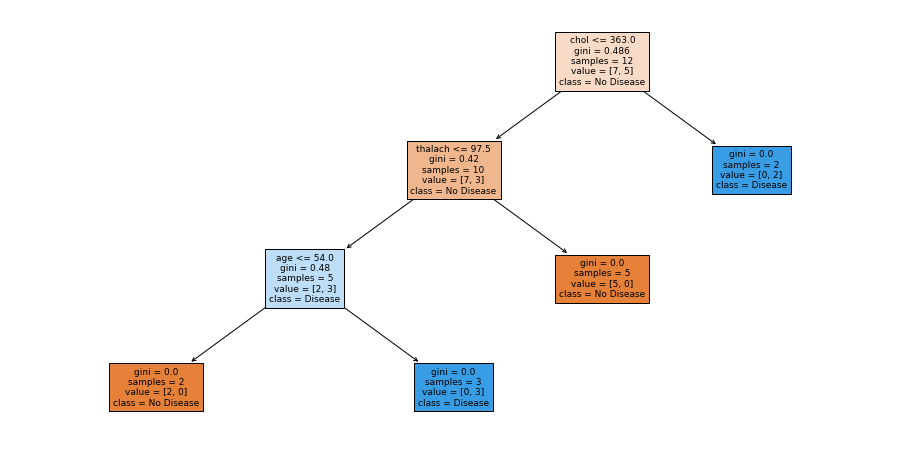

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 8))
plot_tree(dt, feature_names=X.columns, class_names=["No Disease", "Disease"],
          filled=True, max_depth=5, fontsize=9)
plt.show()

In [11]:
for depth in [2, 3, 4, 5, None]:
    dt_d=DecisionTreeClassifier(
    max_depth=depth, random_state=42
)
dt_d.fit(X_train, y_train)
train_acc=dt_d.score(X_train, y_train)
test_acc=dt_d.score(X_test, y_test)
print(depth, train_acc, test_acc)
    

None 1.0 0.6666666666666666


In [21]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(
n_estimators=100, random_state=42
)
rf.fit(X_train, y_train)
pred_rf=rf.predict(X_test)
print(pred_rf[:10])

[0 1 0]


thalach     0.193041
age         0.157609
ca          0.130641
trestbps    0.119736
chol        0.112975
oldpeak     0.106521
exang       0.069937
cp          0.046640
fbs         0.040052
gender      0.022847
dtype: float64


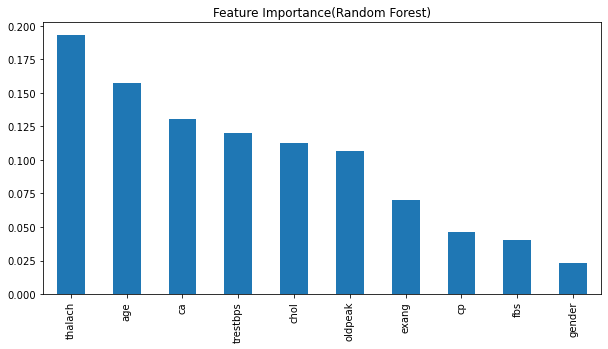

In [26]:
import numpy as py
importances=rf.feature_importances_feat_imp=pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(feat_imp)
feat_imp.plot(kind="bar", figsize=(10, 5), title="Feature Importance(Random Forest)")
plt.show()

In [35]:
for n in [50, 100, 200]:
    for depth in [3, 5, None]:
        rf_t=RandomForestClassifier(n_estimators=n, max_depth=depth,random_state=42)
        rf_t.fit(X_train, y_train)
        acc=rf_t.score(X_test, y_test)
        print("n_estimators =", n, "max_depth =", depth,"->Accuracy:", round(acc, 3))

n_estimators = 50 max_depth = 3 ->Accuracy: 1.0
n_estimators = 50 max_depth = 5 ->Accuracy: 1.0
n_estimators = 50 max_depth = None ->Accuracy: 1.0
n_estimators = 100 max_depth = 3 ->Accuracy: 0.667
n_estimators = 100 max_depth = 5 ->Accuracy: 0.667
n_estimators = 100 max_depth = None ->Accuracy: 0.667
n_estimators = 200 max_depth = 3 ->Accuracy: 0.667
n_estimators = 200 max_depth = 5 ->Accuracy: 0.667
n_estimators = 200 max_depth = None ->Accuracy: 0.667


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
models={
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "KNN (k=5)":KNeighborsClassifier(n_neighbors=5),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(n_estimators=100, random_state=42),
}
results=[]
for name, m in models.items():
    m.fit(X_train, y_train)
    p=m.predict(X_test)
    results.append([
        name,
        accuracy_score(y_test, p),
        precision_score(y_test, p),
        recall_score(y_test, p),
        f1_score(y_test, p),
    ])
comparsion_df=pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 score"])
print(comparsion_df)

C:\Users\ITLAB\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                 Model  Accuracy  Precision  Recall  F1 score
0  Logistic Regression  0.666667        1.0     0.5  0.666667
1            KNN (k=5)  0.333333        0.0     0.0  0.000000
2        Decision Tree  0.666667        1.0     0.5  0.666667
3        Random Forest  0.666667        1.0     0.5  0.666667
